# Step 3 — Forecast Signal Correlation

Measures how well each gauge's reanalysis streamflow correlates with the Floodscan benchmark from Step 2. Spearman ρ is computed across a lag range for each GRRR gauge and the GloFAS reference station, using wet-season (Aug–Nov) daily values. This determines which gauges are useful forecast signals for the action trigger.

**Inputs** (from workflow blob storage):
- `{state}_gauges.parquet` — gauge list from Step 1
- `{state}_floodscan_daily.parquet` — daily mean SFED from Step 2

**Outputs** saved to blob storage:
```
ds-aa-nga-flooding/processed/workflow/{state}_gauge_correlations.parquet
```
Columns: `gauge_id`, `source`, `quality_verified`, `best_r`, `best_lag`, `n_obs`, `latitude`, `longitude`

**Next step**: `04_gauge_selection.ipynb` — filter to a top-N set based on correlation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from scipy import stats as scipy_stats

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import get_blob_name

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

WET_MONTHS = [8, 9, 10, 11]  # Aug–Nov
MIN_LAG = -3
MAX_LAG = 14
MIN_OBS = 60

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]

BLOB_GAUGES = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_gauges.parquet"
BLOB_FS     = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_floodscan_daily.parquet"
BLOB_OUT    = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_gauge_correlations.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load Inputs

In [4]:
df_gauges = stratus.load_parquet_from_blob(BLOB_GAUGES)
df_gauges_grrr   = df_gauges[df_gauges["source"] == "grrr"].copy()
df_gauges_glofas = df_gauges[df_gauges["source"] == "glofas"].iloc[0]
gauge_ids = df_gauges_grrr["gauge_id"].tolist()

print(f"GRRR gauges: {len(gauge_ids)}")
print(f"GloFAS station: {df_gauges_glofas['gauge_id']}")

GRRR gauges: 42
GloFAS station: wuroboki


In [5]:
df_fs = stratus.load_parquet_from_blob(BLOB_FS)
df_fs["date"] = pd.to_datetime(df_fs["date"])
df_fs["month"] = df_fs["date"].dt.month

df_fs_wet = df_fs[
    df_fs["month"].isin(WET_MONTHS)
    & df_fs["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].set_index("date").rename(columns={"mean_sfed": "sfed"})

print(f"Floodscan wet-season days: {len(df_fs_wet):,}  ({ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})")

Floodscan wet-season days: 3,172  (1998–2023)


In [6]:
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_grrr_ra = grrr.process_reanalysis(ds_ra)
df_grrr_ra["date"] = pd.to_datetime(df_grrr_ra["valid_time"]).dt.normalize()
print(f"GRRR reanalysis: {df_grrr_ra['date'].min().date()} to {df_grrr_ra['date'].max().date()}, "
      f"{df_grrr_ra['gauge_id'].nunique()} gauges")

I0616 14:09:54.298690 12906023 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0616 14:09:54.307056 12906041 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(101, generation: 1)


GRRR reanalysis: 1980-01-01 to 2023-12-23, 42 gauges


In [7]:
glofas_station = df_gauges_glofas["gauge_id"]
glofas_blob = get_blob_name("processed", "reanalysis", glofas_station)
df_glofas = stratus.load_parquet_from_blob(glofas_blob)
df_glofas["date"] = pd.to_datetime(df_glofas["time"]).dt.normalize()
df_glofas = df_glofas.rename(columns={"dis24": "discharge"})
print(f"GloFAS ({glofas_station}): {df_glofas['date'].min().date()} to {df_glofas['date'].max().date()}")

GloFAS (wuroboki): 1979-01-01 to 2024-10-31


## Correlation Analysis

Spearman ρ between raw reanalysis streamflow and daily mean Floodscan SFED, across a lag range of `MIN_LAG` to `MAX_LAG` days. The best lag and ρ are recorded per gauge.

In [8]:
def best_lag_corr(df_model, model_col, df_fs_wet):
    """Return (best_r, best_lag, lag_profile) via Spearman across lag range."""
    best_r, best_lag = 0.0, 0
    lag_profile = {}
    for lag in range(MIN_LAG, MAX_LAG + 1):
        sfed_shifted = df_fs_wet["sfed"].shift(-lag)
        valid = df_model[model_col].notna() & sfed_shifted.notna()
        if valid.sum() < MIN_OBS:
            continue
        r, _ = scipy_stats.spearmanr(df_model[model_col][valid], sfed_shifted[valid])
        lag_profile[lag] = r
        if abs(r) > abs(best_r):
            best_r, best_lag = r, lag
    return best_r, best_lag, lag_profile

In [9]:
google_results = []

for _, gauge_row in df_gauges_grrr.iterrows():
    gauge_id = gauge_row["gauge_id"]

    df_sf = (
        df_grrr_ra[df_grrr_ra["gauge_id"] == gauge_id][["date", "streamflow"]]
        .set_index("date")
    )
    merged = df_sf[["streamflow"]].join(df_fs_wet[["sfed"]], how="inner")
    if len(merged) < MIN_OBS:
        continue

    best_r, best_lag, lag_profile = best_lag_corr(merged, "streamflow", merged)

    google_results.append({
        "gauge_id":        gauge_id,
        "source":          "grrr",
        "quality_verified": gauge_row["quality_verified"],
        "best_r":          best_r,
        "best_lag":        best_lag,
        "lag_profile":     lag_profile,
        "n_obs":           len(merged),
        "latitude":        gauge_row["latitude"],
        "longitude":       gauge_row["longitude"],
    })

df_google = (
    pd.DataFrame(google_results)
    .sort_values("best_r", ascending=False)
    .reset_index(drop=True)
)
print(f"Correlations computed for {len(df_google)} GRRR gauges")
df_google[["gauge_id", "quality_verified", "best_r", "best_lag", "n_obs"]]

Correlations computed for 42 GRRR gauges


,gauge_id,quality_verified,best_r,best_lag,n_obs
0,hybas_1120842990,False,0.742052,-3,3172
1,hybas_1120843610,False,0.741784,-3,3172
2,hybas_1120845060,False,0.732323,-3,3172
3,hybas_1120849600,False,0.728169,-3,3172
4,hybas_1120848550,False,0.725664,-3,3172
5,hybas_1121970280,False,0.722795,-3,3172
6,hybas_1120842550,True,0.718800,-3,3172
7,hybas_1120840700,False,0.718775,-3,3172
8,hybas_1120840560,False,0.718564,-3,3172
9,hybas_1120840690,False,0.710538,2,3172


In [10]:
df_glofas_wet = df_glofas[
    df_glofas["date"].dt.month.isin(WET_MONTHS)
    & df_glofas["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].set_index("date")

merged_gf = df_glofas_wet[["discharge"]].join(df_fs_wet[["sfed"]], how="inner")
gf_best_r, gf_best_lag, gf_lag_profile = best_lag_corr(merged_gf, "discharge", merged_gf)

gf_included = True
print(f"GloFAS ({glofas_station}): best ρ = {gf_best_r:.3f} at lag = {gf_best_lag} days, n = {len(merged_gf)}")

GloFAS (wuroboki): best ρ = 0.679 at lag = 1 days, n = 3172


## Plots

In [11]:
CAT_COLORS = {
    "GloFAS":                  "#1EBFB3",
    "Google (high confidence)": "#F4A93B",
    "Google":                   "#007CE0",
}

def get_category(row):
    if row["quality_verified"]:
        return "Google (high confidence)"
    return "Google"

### 1 — Lag Profile Curves

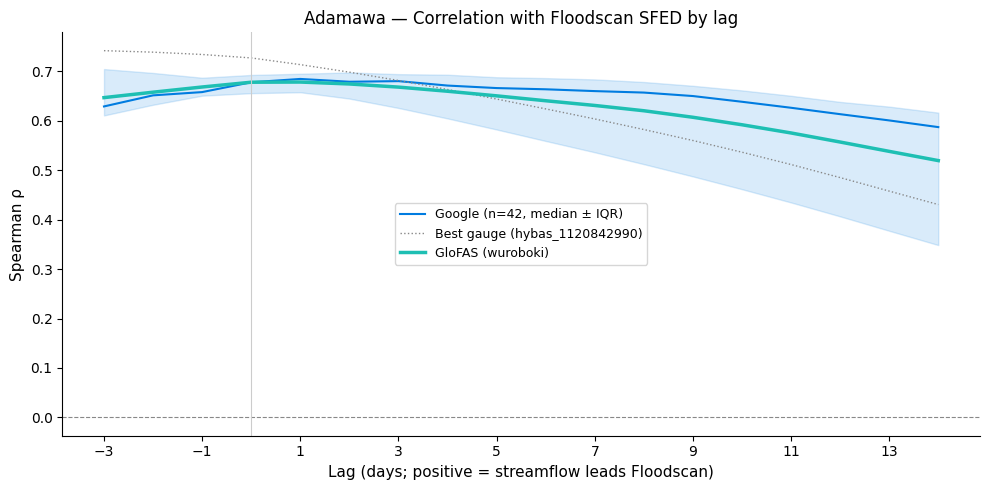

In [12]:
lags = list(range(MIN_LAG, MAX_LAG + 1))

arr_all = np.array(
    [[row["lag_profile"].get(lag, np.nan) for lag in lags] for _, row in df_google.iterrows()],
    dtype=float,
)
best_idx = df_google["best_r"].idxmax()
best_profile = [df_google.loc[best_idx, "lag_profile"].get(lag, np.nan) for lag in lags]
gf_profile   = [gf_lag_profile.get(lag, np.nan) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(
    lags,
    np.nanpercentile(arr_all, 25, axis=0),
    np.nanpercentile(arr_all, 75, axis=0),
    color=CAT_COLORS["Google"], alpha=0.15,
)
ax.plot(lags, np.nanmedian(arr_all, axis=0), color=CAT_COLORS["Google"], linewidth=1.5,
        label=f"Google (n={len(arr_all)}, median ± IQR)")
ax.plot(lags, best_profile, color="#888888", linewidth=1, linestyle=":",
        label=f"Best gauge ({df_google.loc[best_idx, 'gauge_id']})")
if gf_included:
    ax.plot(lags, gf_profile, color=CAT_COLORS["GloFAS"], linewidth=2.5,
            label=f"GloFAS ({glofas_station})")

ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--")
ax.axvline(0, color="#cccccc", linewidth=0.8)
ax.set_xlabel("Lag (days; positive = streamflow leads Floodscan)", fontsize=11)
ax.set_ylabel("Spearman ρ", fontsize=11)
ax.set_title(f"{STATE} — Correlation with Floodscan SFED by lag", fontsize=12)
ax.set_xticks(range(MIN_LAG, MAX_LAG + 1, 2))
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_corr_lag_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

### 2 — Cleveland Dot Plot

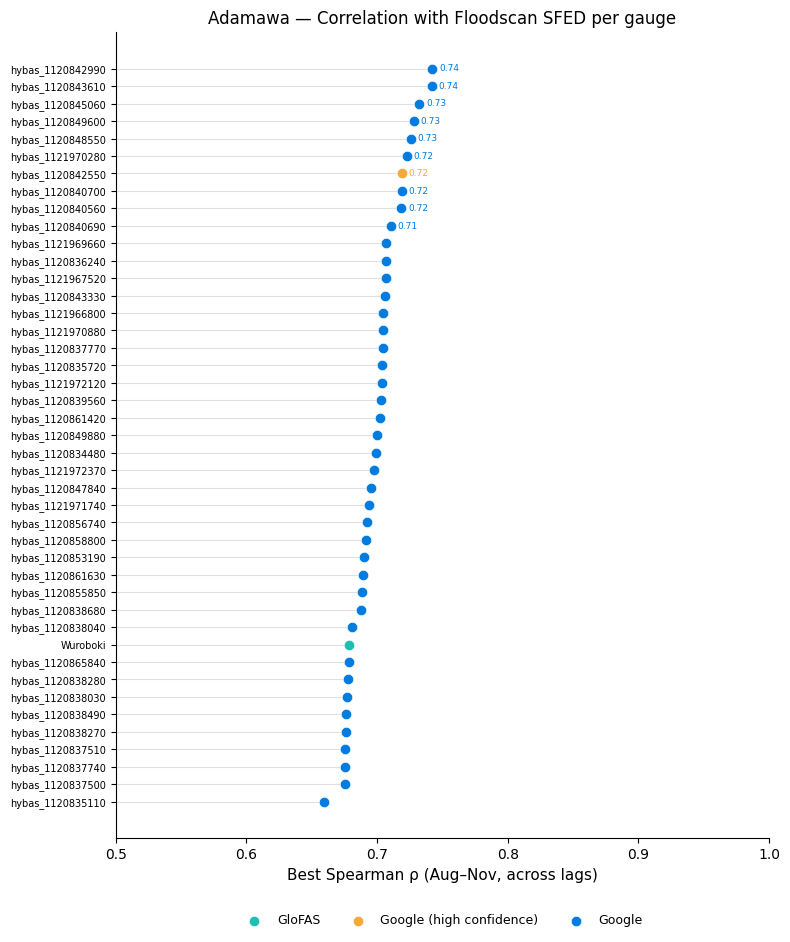

In [13]:
df_dot = df_google[["gauge_id", "best_r", "quality_verified"]].copy()
df_dot["category"] = df_dot.apply(get_category, axis=1)

if gf_included:
    gf_dot_row = pd.DataFrame([{
        "gauge_id": glofas_station.capitalize(),
        "best_r": gf_best_r,
        "quality_verified": False,
        "category": "GloFAS",
    }])
    df_dot = pd.concat([df_dot, gf_dot_row], ignore_index=True)

df_dot = df_dot.sort_values("best_r", ascending=True).reset_index(drop=True)

# Top 10 GRRR gauges (df_google is sorted descending by best_r)
top10_ids = set(df_google.iloc[:10]["gauge_id"].tolist())

X_MIN, X_MAX = 0.5, 1.0

fig, ax = plt.subplots(figsize=(8, max(5, len(df_dot) * 0.22)))

for i, row in df_dot.iterrows():
    color = CAT_COLORS[row["category"]]
    ax.hlines(i, X_MIN, row["best_r"], color="#e0e0e0", linewidth=0.8, zorder=1)
    ax.scatter(row["best_r"], i, color=color, s=55, zorder=3,
               edgecolors="white", linewidths=0.4)
    if row["gauge_id"] in top10_ids:
        ax.annotate(
            f"{row['best_r']:.2f}",
            xy=(row["best_r"], i),
            xytext=(5, 0), textcoords="offset points",
            fontsize=6.5, va="center", color=color,
        )

ax.set_xlim(X_MIN, X_MAX)
ax.set_yticks(range(len(df_dot)))
ax.set_yticklabels(df_dot["gauge_id"], fontsize=7)
ax.set_xlabel("Best Spearman ρ (Aug–Nov, across lags)", fontsize=11)
ax.set_title(f"{STATE} — Correlation with Floodscan SFED per gauge", fontsize=12)

handles = [
    plt.scatter([], [], color=color, s=55, label=cat,
                edgecolors="white", linewidths=0.4)
    for cat, color in CAT_COLORS.items()
]
ax.legend(handles=handles, ncol=len(CAT_COLORS),
          loc="upper center", bbox_to_anchor=(0.5, -0.08),
          fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_corr_dot_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 3 — Gauge Map

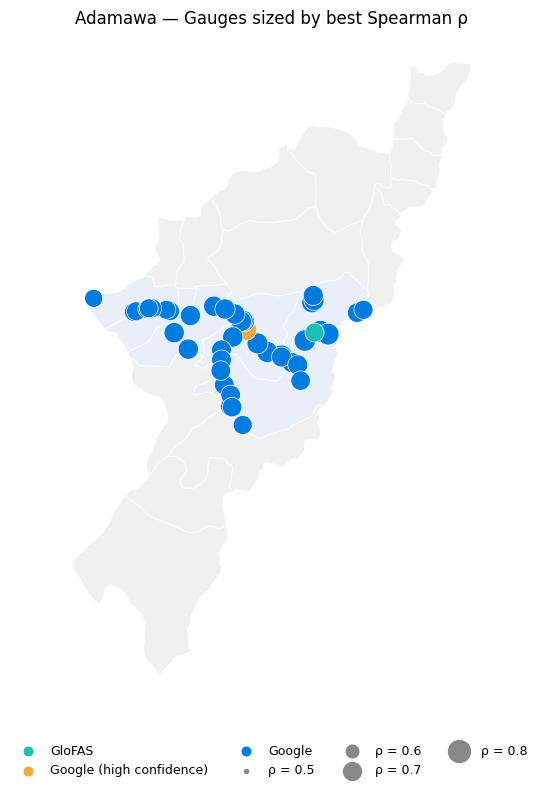

In [14]:
import geopandas as gpd

gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_state   = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_target  = gdf_lga[gdf_lga["ADM2_PCODE"].isin(cfg["lga_pcodes"])].copy()
gdf_nontarget = gdf_state[~gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]

R_MIN, R_MAX = 0.5, 0.8
SIZE_MIN, SIZE_MAX = 20, 300

def r_to_size(r):
    return SIZE_MIN + (np.clip(r, R_MIN, R_MAX) - R_MIN) / (R_MAX - R_MIN) * (SIZE_MAX - SIZE_MIN)

df_map = df_google[["gauge_id", "best_r", "quality_verified", "latitude", "longitude"]].copy()
df_map["category"] = df_map.apply(get_category, axis=1)
df_map["color"] = df_map["category"].map(CAT_COLORS)
df_map["size"]  = df_map["best_r"].apply(r_to_size)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_nontarget.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_target.plot(ax=ax, color="#E8EFF8", edgecolor="white", linewidth=0.5)

ax.scatter(
    df_map["longitude"], df_map["latitude"],
    c=df_map["color"], s=df_map["size"],
    zorder=5, edgecolors="white", linewidths=0.5,
)

if gf_included:
    ax.scatter(
        df_gauges_glofas["longitude"], df_gauges_glofas["latitude"],
        c=CAT_COLORS["GloFAS"], s=r_to_size(gf_best_r),
        zorder=6, edgecolors="white", linewidths=0.5,
    )

for cat, color in CAT_COLORS.items():
    ax.scatter([], [], color=color, s=60, label=cat, edgecolors="white", linewidths=0.5)
for r_val in [0.5, 0.6, 0.7, 0.8]:
    ax.scatter([], [], color="#888888", s=r_to_size(r_val),
               label=f"ρ = {r_val:.1f}", edgecolors="white", linewidths=0.5)

ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.04),
          fontsize=9, frameon=False)
ax.set_axis_off()
ax.set_title(f"{STATE} — Gauges sized by best Spearman ρ", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_corr_gauge_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

In [15]:
pd.DataFrame([
    {
        "Model": "GloFAS reanalysis",
        "Source": glofas_station.capitalize(),
        "Best ρ": round(gf_best_r, 3),
        "Best lag (days)": gf_best_lag,
    },
    {
        "Model": "Google GRRR (median)",
        "Source": f"{len(df_google)} gauges",
        "Best ρ": round(df_google["best_r"].median(), 3),
        "Best lag (days)": int(df_google["best_lag"].median()),
    },
    {
        "Model": "Google GRRR (best gauge)",
        "Source": df_google.loc[best_idx, "gauge_id"],
        "Best ρ": round(df_google.loc[best_idx, "best_r"], 3),
        "Best lag (days)": df_google.loc[best_idx, "best_lag"],
    },
])

,Model,Source,Best ρ,Best lag (days)
0,GloFAS reanalysis,Wuroboki,0.679,1
1,Google GRRR (median),42 gauges,0.701,2
2,Google GRRR (best gauge),hybas_1120842990,0.742,-3


## Save

In [16]:
keep = ["gauge_id", "source", "quality_verified", "best_r", "best_lag", "n_obs",
        "latitude", "longitude"]

df_out = df_google[keep].copy()

if gf_included:
    gf_out_row = pd.DataFrame([{
        "gauge_id":         glofas_station,
        "source":           "glofas",
        "quality_verified": None,
        "best_r":           round(gf_best_r, 4),
        "best_lag":         gf_best_lag,
        "n_obs":            len(merged_gf),
        "latitude":         float(df_gauges_glofas["latitude"]),
        "longitude":        float(df_gauges_glofas["longitude"]),
    }])
    df_out = pd.concat([df_out, gf_out_row], ignore_index=True)

stratus.upload_parquet_to_blob(df_out, BLOB_OUT)
n_gf = 1 if gf_included else 0
print(f"Saved {len(df_out)} rows ({len(df_out) - n_gf} GRRR + {n_gf} GloFAS) to {BLOB_OUT}")

Saved 43 rows (42 GRRR + 1 GloFAS) to ds-aa-nga-flooding/processed/workflow/adamawa_gauge_correlations.parquet
